In [1]:
# Downloads and unzips wine data through UCI Database
!wget https://archive.ics.uci.edu/static/public/186/wine+quality.zip
!unzip wine+quality.zip

--2024-06-20 16:36:10--  https://archive.ics.uci.edu/static/public/186/wine+quality.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wine+quality.zip’

wine+quality.zip        [ <=>                ]  89.21K   486KB/s    in 0.2s    

2024-06-20 16:36:10 (486 KB/s) - ‘wine+quality.zip’ saved [91353]

Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [2]:
import pandas as pd

In [3]:
# open and read the data
opened_red = open("/content/winequality-red.csv",'r')
opened_white = open("/content/winequality-white.csv",'r')
red_lines = opened_red.readlines()
white_lines = opened_white.readlines()
opened_red.close()
opened_white.close()

In [4]:
# remove the name lines
red_lines.pop(0)
white_lines.pop(0)
all_data = []
for line in red_lines:
  # remove last character and split using ;
  split_line = line[:-1].split(';')
  # convert numbers in line to float
  processed_line = [float(i) for i in split_line]
  # add 0 for wine type
  processed_line.append(0)
  all_data.append(processed_line)
for line in white_lines:
  # remove last character and split using ;
  split_line = line[:-1].split(';')
  # convert numbers in line to float
  processed_line = [float(i) for i in split_line]
  # add 1 for wine type
  processed_line.append(1)
  all_data.append(processed_line)

In [5]:
# convert to dataframe
data = pd.DataFrame(all_data)
# shuffle
data = data.sample(frac=1,random_state=0)
data = data.reset_index(drop=True)

In [6]:
# here's a quick visualization of what our data looks like
X = data.iloc[:,:-1]
X.columns = ["fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides","free_sulfur_dioxide","total_sulfur_dioxide","density","pH","sulphates","alcohol","quality"]
y = data.iloc[:,-1]
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,6.3,0.18,0.24,3.4,0.053,20.0,119.0,0.99373,3.11,0.52,9.2,6.0
1,6.8,0.14,0.18,1.4,0.047,30.0,90.0,0.99164,3.27,0.54,11.2,6.0
2,7.3,0.22,0.50,13.7,0.049,56.0,189.0,0.99940,3.24,0.66,9.0,6.0
3,7.6,0.67,0.14,1.5,0.074,25.0,168.0,0.99370,3.05,0.51,9.3,5.0
4,7.3,0.21,0.29,1.6,0.034,29.0,118.0,0.99170,3.30,0.50,11.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.5,0.22,0.28,3.7,0.059,29.0,151.0,0.99177,3.23,0.41,12.1,7.0
6493,6.5,0.13,0.37,1.0,0.036,48.0,114.0,0.99110,3.41,0.51,11.5,8.0
6494,6.8,0.20,0.59,0.9,0.147,38.0,132.0,0.99300,3.05,0.38,9.1,6.0
6495,6.6,0.22,0.37,1.2,0.059,45.0,199.0,0.99300,3.37,0.55,10.3,7.0


In [7]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2)
km = km.fit(X)
# get all the differences in predictions
differences = km.labels_-y
#extract only those cells where the difference between prediction and actual gives you 0. This is because those cells will have made a correct prediction
#the below line of code selects all those cells in differences with a value of 0.
# Effectively, you're selecting only those values where predicted value from k means met the actual value
correct = differences[differences == 0]
# add them all up and divide by number of samples
len(correct)/len(y)

#IMPORTANT CAVEAT: Trying to find the accuracy of a clustering algorithm may not always be the best idea.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


0.21440664922271818

In [8]:
import matplotlib.pyplot as plt

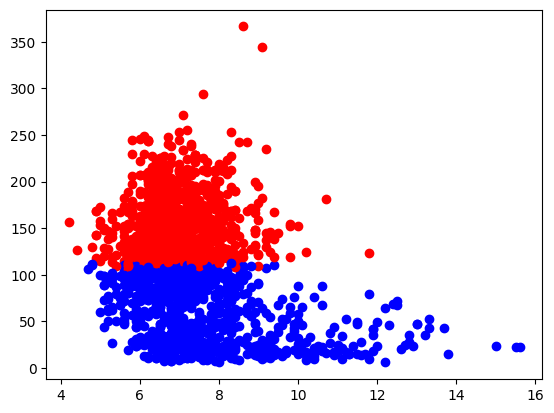

In [9]:
colors = ['red','blue']
for i in range(2000):
  sample = X.iloc[i]
  # plot each point with its color
  plt.scatter(sample.iloc[0],sample.iloc[6],c=colors[km.labels_[i]])

In [10]:
# a very clear divide on just one of twelve features,
# so standardizing is very important in k means

In [11]:
# import a bunch of things
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [12]:
# have a list of models and their names (names look weird but they all have same length for formatting)
models = [LogisticRegression(max_iter=10000), RandomForestClassifier(), SVC(), GaussianNB()]
model_names = ["logistic regression   ", "random forest         ", "support vector machine", "naive bayes           "]

In [13]:
# separate the last 200 elements for testing
train_X = X.iloc[:-200]
test_X = X.iloc[-200:]
train_y = y.iloc[:-200]
test_y = y.iloc[-200:]

In [14]:
# we want to check accuracies for diff nums of dimensions
for num_dim in range(1,12):
  pca = PCA(n_components=num_dim)
  pca.fit(train_X)
  t_mat = pca.components_
  # reduce dimensions down to i dimensions
  # this is a bit convoluted of a listcomp, but
  # we just multiply the matrix by the sample for
  # all of the samples
  # we used .iloc to loop through samples and not columns
  new_train_X = [t_mat @ sample for sample in train_X.iloc]
  new_test_X = [t_mat @ sample for sample in test_X.iloc]
  train_y = y.iloc[:-200]
  test_y = y.iloc[-200:]
  # run through each model and print results
  # print out the dimensions and explained variance
  print(num_dim, "dimensions")
  print("explained variances:")
  print(pca.explained_variance_)
  for model_num in range(4):
    model = models[model_num].fit(train_X,train_y)
    # for each of the models, we fit it and print the result
    print(model_names[model_num], end = ' ')
    print(model.score(test_X, test_y))
  print()

1 dimensions
explained variances:
[3385.848373]
logistic regression    0.995
random forest          0.995
support vector machine 0.945
naive bayes            0.97

2 dimensions
explained variances:
[3385.848373    143.78590958]
logistic regression    0.995
random forest          1.0
support vector machine 0.945
naive bayes            0.97

3 dimensions
explained variances:
[3385.848373    143.78590958   17.11010836]
logistic regression    0.995
random forest          1.0
support vector machine 0.945
naive bayes            0.97

4 dimensions
explained variances:
[3.38584837e+03 1.43785910e+02 1.71101084e+01 1.74649767e+00]
logistic regression    0.995
random forest          0.995
support vector machine 0.945
naive bayes            0.97

5 dimensions
explained variances:
[3.38584837e+03 1.43785910e+02 1.71101084e+01 1.74649767e+00
 1.23121394e+00]
logistic regression    0.995
random forest          0.995
support vector machine 0.945
naive bayes            0.97

6 dimensions
explained var

In [15]:
# the very high variance from the first and second dimension are probably
# both from the very big feature